# Networks: shortest distance or fastest access?

An original geospatial extension of **Interactive Model Railroad**, Probably Nick:
[catalog](https://github.com/magiccreator-ai/awesome-gpt-6-astra#interactive-model-railroad) ·
[creator post](https://x.com/nickfromlater/status/2097355845524726084) ·
[creator demo](https://alder-valley-rail-atelier.nickfromlater.chatgpt.site/).

**Learn:** distinguish Euclidean distance, graph connectivity and weighted travel cost.
**Predict:** will a slower bridge change the shortest geometric route or the fastest route?
This is a synthetic street graph, with assumed travel times rather than observed traffic.


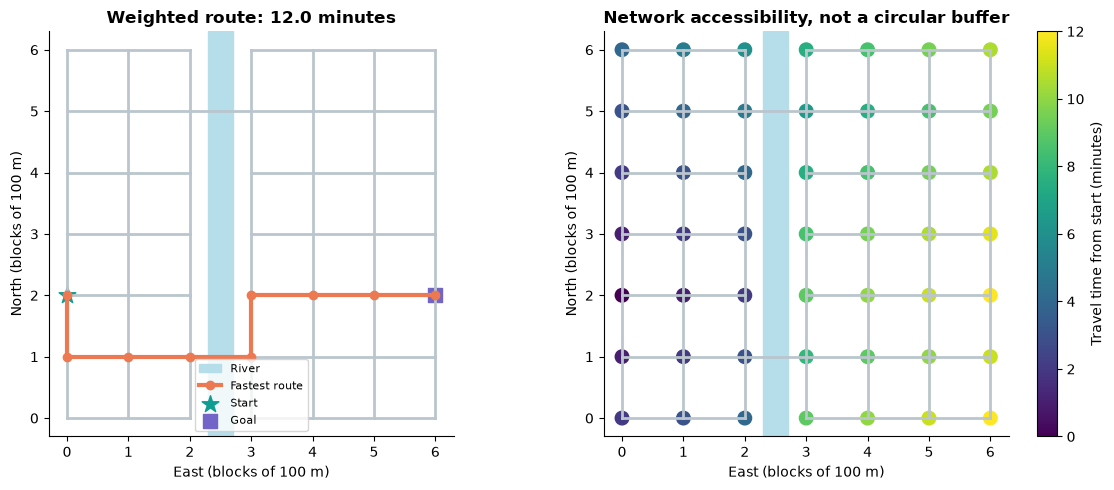

In [1]:
import heapq
import numpy as np
import matplotlib.pyplot as plt
from astra_utils import style
style()
n = 7
nodes = [(x,y) for y in range(n) for x in range(n)]
edges = []
for x,y in nodes:
    for b in [(x+1,y),(x,y+1)]:
        if b not in nodes:
            continue
        # River between columns 2 and 3; crossings exist only at y=1 and y=5.
        crossing = x == 2 and b[0] == 3
        if crossing and y not in [1,5]:
            continue
        cost = 1.0 if not crossing else (5.0 if y == 1 else 1.5)
        edges.append(((x,y),b,cost))

def shortest_paths(source, edges):
    graph = {node:[] for node in nodes}
    for a,b,w in edges:
        if w < 0:
            raise ValueError('Dijkstra requires nonnegative weights')
        graph[a].append((b,w)); graph[b].append((a,w))
    dist, parent, heap = {source:0.0}, {}, [(0.0,source)]
    while heap:
        cost,a = heapq.heappop(heap)
        if cost != dist[a]:
            continue
        for b,w in graph[a]:
            candidate = cost+w
            if candidate < dist.get(b,float('inf')):
                dist[b],parent[b] = candidate,a
                heapq.heappush(heap,(candidate,b))
    return dist,parent

start, goal = (0,2),(6,2)
distance, parent = shortest_paths(start,edges)
path = [goal]
while path[-1] != start:
    path.append(parent[path[-1]])
path = np.array(path[::-1])
fig, axes = plt.subplots(1,2,figsize=(12,5))
for ax in axes:
    ax.axvspan(2.3,2.7,color='#b6ddea',label='River')
    for a,b,w in edges:
        ax.plot([a[0],b[0]],[a[1],b[1]],color='#bac5cd',lw=2)
    ax.set(xlabel='East (blocks of 100 m)',ylabel='North (blocks of 100 m)',aspect='equal')
axes[0].plot(*path.T,'o-',lw=3,color='#ed7953',label='Fastest route')
axes[0].scatter(*start,s=160,marker='*',color='#0f9d92',label='Start')
axes[0].scatter(*goal,s=100,marker='s',color='#7365c7',label='Goal')
axes[0].set_title(f'Weighted route: {distance[goal]:.1f} minutes')
axes[0].legend(fontsize=8)
im = axes[1].scatter(*np.array(nodes).T,c=[distance[p] for p in nodes],s=95,cmap='viridis')
fig.colorbar(im,ax=axes[1],label='Travel time from start (minutes)')
axes[1].set_title('Network accessibility, not a circular buffer')
fig.tight_layout()
plt.show()


The river removes edges; the bridge delay changes edge weights. These are distinct interventions.
A straight radius ignores both. Dijkstra grows a frontier of least known cost and is valid here
because every travel time is nonnegative. A predecessor map lets us recover the actual route.


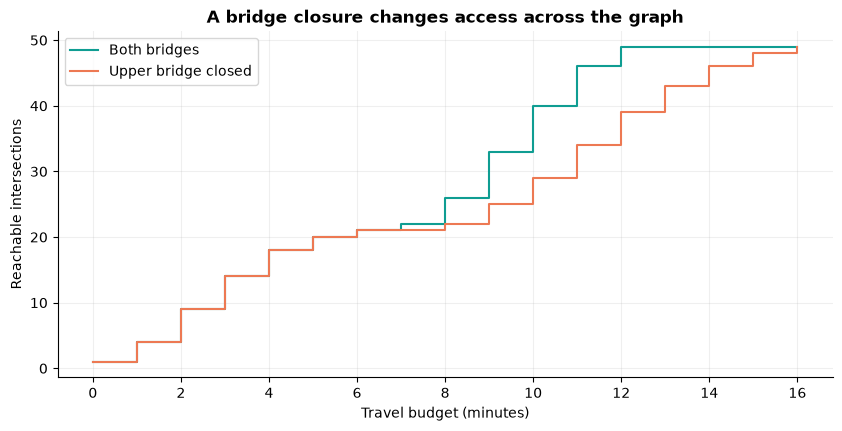

Goal travel time after closure: 12.0 minutes


In [2]:
closed_edges = [(a,b,w) for a,b,w in edges if not (a == (2,5) and b == (3,5))]
closed, _ = shortest_paths(start,closed_edges)
budgets = np.arange(0,17)
baseline = [sum(t <= b for t in distance.values()) for b in budgets]
closure = [sum(t <= b for t in closed.values()) for b in budgets]
plt.step(budgets,baseline,where='post',label='Both bridges')
plt.step(budgets,closure,where='post',label='Upper bridge closed')
plt.xlabel('Travel budget (minutes)')
plt.ylabel('Reachable intersections')
plt.title('A bridge closure changes access across the graph')
plt.legend()
plt.grid(alpha=.2)
plt.show()
print('Goal travel time after closure:',closed[goal],'minutes')
assert distance[start] == 0 and len(distance) == len(nodes)
assert all(closed[node] >= distance[node] for node in nodes)


**Experiment:** make the lower crossing cost 1 minute and rerun. Predict whether the fastest path
moves before inspecting the plot. Then remove both bridges and handle an unreachable destination
with `distance.get(goal, float('inf'))` instead of assuming every node can be reached.

**Explain:** why can two intersections equally far from the start have different travel times?
Real accessibility also depends on direction, modes, schedules, congestion and mobility needs.
